## Анализ данных на основе данных "Give Me Some Credit"

In [2]:
# Импортирую все необходимые для работы библиотеки
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Для начала наша задача состоит в том, чтобы взглянуть на небольшой кусочек предоставленных данных.

In [3]:
df_c = pd.read_csv(r"C:\Users\HP\archive\cs-training.csv")
df_c.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
df_c.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

##### Как мы видим выше, в данном датасете есть 150 000 строк и 12 колонок.
##### Колонка 'Unnamed: 0' не несет ни какой информации, поэтому я данную колонку удалю из датасета.
##### В колонке 'MonthlyIncome' мы видим примерно 30 000 пропусков, это составляет 20% от всех данных в данных колонках.
##### В колонке 'NumberOfDependents' мы так же видим 4 000 пропусков, это составляет 3% от всех данных в данных колонках.

#### Вывод: Исходя из данных, я обнаружил пропуски в ключевых признаках, особенно в MonthlyIncome (примерно 20%), что требует дальнейшей обработки.

In [8]:
# Удаляем дубликаты и столбец Unnamed
df_c = df_c.drop_duplicates()
df_c = df_c.drop(columns=['Unnamed: 0'])
df_c.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [9]:
df_c.describe(include=[np.number])

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


##### Теперь мы посчитаем Таргет для колонки SeriousDlqin2yrs, где идут следующие ответы: 0 → клиент нормальный (не было серьёзной просрочки) и 1 → клиент дефолтный (была серьёзная просрочка)

In [14]:
counts = df_c['SeriousDlqin2yrs'].value_counts()
percents = df_c['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
pd.DataFrame({'Количество': counts, 'Проценты (%)': percents})

,Количество,Проценты (%)
SeriousDlqin2yrs,,
0,139974,93.316
1,10026,6.684


#### Вывод: Из данных выше мы видим, что целевая переменная несбалансирована: доля дефолтов составляет около 6.7%, что типично для задач кредитного скоринга.

##### Теперь мы переходим к анализу поведения клиентов

In [20]:
# Посчитаем средние для возраста и просрочек, медиану для дохода
g = df_c.groupby('SeriousDlqin2yrs')
late_0, late_1 = g['NumberOfTimes90DaysLate'].mean()[0], g['NumberOfTimes90DaysLate'].mean()[1]
age_0, age_1 = g['age'].mean()[0], g['age'].mean()[1]
inc_0, inc_1 = g['MonthlyIncome'].median()[0], g['MonthlyIncome'].median()[1]

print(f"1. У кого больше просрочек? У группы 1 ({late_1:.2f} в среднем) против группы 0 ({late_0:.2f} в среднем).")
print(f"2. Есть ли разница по возрасту? Группа 1 в среднем моложе: {age_1:.1f} лет против {age_0:.1f} лет у группы 0.")
print(f"3. Доход влияет? Да, у группы 1 медианный доход ниже: {inc_1:.0f} против {inc_0:.0f} у группы 0.")

1. У кого больше просрочек? У группы 1 (2.09 в среднем) против группы 0 (0.14 в среднем).
2. Есть ли разница по возрасту? Группа 1 в среднем моложе: 45.9 лет против 52.8 лет у группы 0.
3. Доход влияет? Да, у группы 1 медианный доход ниже: 4500 против 5466 у группы 0.


#### Я провёл анализ факторов, влияющих на дефолт клиентов.

#### Обнаружил, что ключевым драйвером риска являются просрочки:  
#### у дефолтных клиентов среднее количество просрочек более чем в 10 раз выше.

#### Также заметил, что дефолтные клиенты в среднем моложе,  
#### что может говорить о менее стабильном финансовом поведении.

#### Кроме того, у них ниже уровень дохода,  
#### что логично увеличивает вероятность невыплат.

#### Таким образом, просрочки, доход и возраст являются значимыми признаками для построения скоринговой модели.

###### Далее мы подготовим данные для дальнейшей работы с ними.
В колонке "MonthlyIncome" мы имеем 20% пропусков, заполним пропуски медианными значениями, так как распределение имеет выбросы и среднее значение неустойчиво.

In [22]:
df_c['MonthlyIncome'] = df_c['MonthlyIncome'].fillna(df_c['MonthlyIncome'].median())

В колонке "NumberOfDependents" мы так же заполним пропуски медианными значениями.

In [24]:
df_c['NumberOfDependents'] = df_c['NumberOfDependents'].fillna(df_c['NumberOfDependents'].median())

В колонке "Age" я удалю значение = 0, так как данное значение нам особо не поможет.

In [25]:
df_c = df_c[df_c['age'] > 0]

Далее я ограничу выбросы с помощью clip (winsorization), чтобы снизить влияние экстремальных значений на модель

In [29]:
df_c['NumberOfTimes90DaysLate'] = df_c['NumberOfTimes90DaysLate'].clip(upper=10)
df_c['NumberOfTime30-59DaysPastDueNotWorse'] = df_c['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=10)
df_c['NumberOfTime60-89DaysPastDueNotWorse'] = df_c['NumberOfTime60-89DaysPastDueNotWorse'].clip(upper=10)
upper_limit = df_c['DebtRatio'].quantile(0.99)
df_c['DebtRatio'] = df_c['DebtRatio'].clip(upper=upper_limit)
upper_income = df_c['MonthlyIncome'].quantile(0.99)
df_c['MonthlyIncome'] = df_c['MonthlyIncome'].clip(upper=upper_income)

In [30]:
df_c.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000
mean,0.066840,6.048472,52.295555,0.263228,316.550593,6142.446263,8.452776,0.107921,1.018233,0.082634,0.737405
std,0.249746,249.756203,14.771298,0.809436,906.962903,3835.691425,5.145964,0.635483,1.129772,0.534149,1.107020
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3903.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154176,52.000000,0.000000,0.366503,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559044,63.000000,0.000000,0.868257,7400.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,10.000000,4979.001600,23000.000000,58.000000,10.000000,54.000000,10.000000,20.000000


Я обнаружил аномальные значения в RevolvingUtilization и ограничу их по 99 перцентилю

In [31]:
upper_limit = df_c['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
df_c['RevolvingUtilizationOfUnsecuredLines'] = df_c['RevolvingUtilizationOfUnsecuredLines'].clip(upper=upper_limit)

In [32]:
df_c.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000,149999.000000
mean,0.066840,0.320491,52.295555,0.263228,316.550593,6142.446263,8.452776,0.107921,1.018233,0.082634,0.737405
std,0.249746,0.352149,14.771298,0.809436,906.962903,3835.691425,5.145964,0.635483,1.129772,0.534149,1.107020
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3903.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154176,52.000000,0.000000,0.366503,5400.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559044,63.000000,0.000000,0.868257,7400.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.092958,109.000000,10.000000,4979.001600,23000.000000,58.000000,10.000000,54.000000,10.000000,20.000000


Я ограничил экстремальные значения, но оставил распределение, так как DebtRatio может иметь большие значения в реальных данных

## Построление модели

In [40]:
x = df_c.drop('SeriousDlqin2yrs', axis=1)
y = df_c['SeriousDlqin2yrs']

In [41]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_proba = model.predict_proba(x_test)[:, 1]

In [43]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_proba)
print(roc_auc)

0.8367274554711591


#### Я построил baseline модель кредитного скоринга на основе логистической регрессии.
##### После подготовки данных и обработки выбросов модель показала ROC-AUC около 0.84, что говорит о хорошем качестве разделения клиентов по риску.

In [46]:
coef = pd.DataFrame({
    'feature': x.columns,
    'coef': model.coef_[0]
})

coef.sort_values(by='coef', ascending=False)

,feature,coef
0,RevolvingUtilizationOfUnsecuredLines,2.266284
6,NumberOfTimes90DaysLate,0.505386
2,NumberOfTime30-59DaysPastDueNotWorse,0.368060
8,NumberOfTime60-89DaysPastDueNotWorse,0.161152
7,NumberRealEstateLoansOrLines,0.117704
9,NumberOfDependents,0.052687
5,NumberOfOpenCreditLinesAndLoans,0.036641
4,MonthlyIncome,-0.000052
3,DebtRatio,-0.000084
1,age,-0.015002


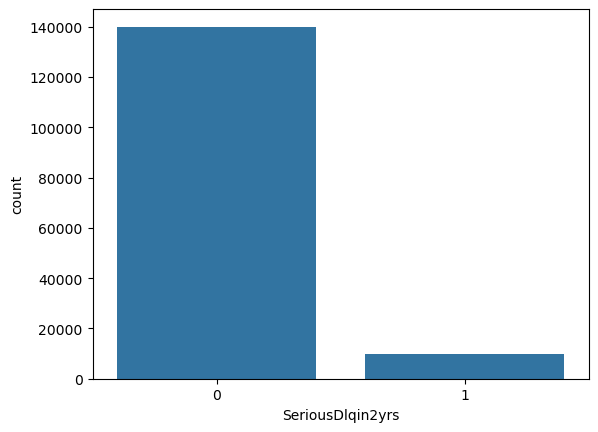

In [51]:
sns.countplot(x='SeriousDlqin2yrs', data=df_c)
plt.show()

# Вывод: 
#### Я построил модель логистической регрессии для задачи кредитного скоринга и получил ROC-AUC около 0.84 процентов. 
#### При анализе коэффициентов модели я выявил ключевые факторы риска: 
####  - Наибольшее влияние оказывают показатели просрочек — особенно длительные просрочки более 90 дней, а также уровень использования кредитного лимита.
####  - Это логично с точки зрения бизнеса, так как эти признаки напрямую отражают платёжоспособность клиента.
####  - В то же время такие факторы, как возраст и доход, снижают вероятность дефолта, что также соответствует ожиданиям:
####  более зрелые и финансово стабильные клиенты менее рискованные.
#### Таким образом, модель выявляет интерпретируемые и бизнес-значимые закономерности.